# LLM-based PICO Extraction: Zero-shot vs Few-shot Prompting

**Author:** Saisha Hiray
**Task:** EBM-NLP Structured Information Extraction  
**Design axis:** Prompting strategy comparison using `google/flan-t5-base`

This notebook compares three prompting strategies for extracting Participants, Interventions and Outcomes (PIO) from clinical trial abstracts:

1. **Zero-shot** — instruction only, no examples  
2. **Few-shot** — three worked examples prepended to the prompt  
3. **Few-shot + JSON** — same as (2) but output forced into JSON format

**Hypothesis:** Few-shot will outperform zero-shot due to in-context domain grounding. Adding the JSON constraint will further improve precision by reducing off-topic generation.

**Evaluation:** token-level Precision, Recall and F1 against EBM-NLP gold spans, plus coverage and downstream usability tests. 

## Imports

In [23]:
import os
import re
import json
import tarfile
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter
from transformers import T5ForConditionalGeneration, T5Tokenizer
import torch
import warnings
warnings.filterwarnings('ignore')

## Loading the EBM-NLP dataset

Downloading the dataset directly from the official repository (`bepnye/EBM-NLP`)

In [24]:
DATA_DIR     = Path("./ebm_nlp_2_00")
ARCHIVE      = Path("./ebm_nlp_2_00.tar.gz")
DOWNLOAD_URL = "https://github.com/bepnye/EBM-NLP/raw/master/ebm_nlp_2_00.tar.gz"

if not DATA_DIR.exists():
    if not ARCHIVE.exists():
        print("Downloading dataset...")
        urllib.request.urlretrieve(DOWNLOAD_URL, ARCHIVE)
        print("Download complete.")
    print("Extracting...")
    with tarfile.open(ARCHIVE) as f:
        f.extractall(".")
    print("Done.")
else:
    print("Dataset already exists at", DATA_DIR.resolve())

DOCS_DIR  = DATA_DIR / "documents"
ANNOT_DIR = DATA_DIR / "annotations" / "aggregated" / "hierarchical_labels"

assert DOCS_DIR.exists(), "documents folder missing"
assert ANNOT_DIR.exists(), "annotations folder missing"
print("Paths OK.")

Dataset already exists at /Users/saishahiray/Desktop/IATA-Coursework-Group2/notebook/ebm_nlp_2_00
Paths OK.


## Data loading utilities

These helper functions match the pattern used across the group's other notebooks so that evaluation numbers are directly comparable.

In [25]:
FIELDS = ["participants", "interventions", "outcomes"]

def get_doc_ids(split="train", label_type="participants"):
    folder  = "test/gold" if split == "test" else split
    ann_dir = ANNOT_DIR / label_type / folder
    return sorted([p.stem.split(".")[0] for p in ann_dir.glob("*.AGGREGATED.ann")])

def load_tokens(doc_id):
    path = DOCS_DIR / f"{doc_id}.tokens"
    if not path.exists():
        return None
    return path.read_text(encoding="utf-8").strip().split("\n")

def load_ann_labels(doc_id, field, split="train"):
    folder = "test/gold" if split == "test" else split
    path   = ANNOT_DIR / field / folder / f"{doc_id}.AGGREGATED.ann"
    if not path.exists():
        return []
    out = []
    for line in path.read_text(encoding="utf-8").strip().split("\n"):
        line = line.strip()
        if line:
            try:
                out.append(int(line))
            except ValueError:
                out.append(0)
    return out

def get_abstract_text(doc_id):
    tokens = load_tokens(doc_id)
    return " ".join(tokens) if tokens else ""

def get_gold_tokens(doc_id, field, split="test"):
    tokens = load_tokens(doc_id)
    labels = load_ann_labels(doc_id, field, split)
    if not tokens or not labels:
        return set()
    return {tok.lower() for tok, lab in zip(tokens, labels) if lab != 0}

def get_gold_spans(doc_id, field, split="test"):
    tokens = load_tokens(doc_id)
    labels = load_ann_labels(doc_id, field, split)
    if not tokens or not labels:
        return []
    spans, current = [], []
    for tok, lab in zip(tokens, labels):
        if lab != 0:
            current.append(tok)
        else:
            if current:
                spans.append(" ".join(current))
                current = []
    if current:
        spans.append(" ".join(current))
    return spans

print("Functions loaded.")

Functions loaded.


## Selecting evaluation and few-shot documents

We use the project's locked 50-document test set — the intersection of the test split for all three PICO fields, capped at 50 — defined in `src/data.py` and shared across notebooks 02–07. Three additional **training-split** documents serve as few-shot examples; these are never included in evaluation.

In [26]:
import sys, os
for candidate in ['..', '.', '/content']:
    if os.path.exists(os.path.join(candidate, 'src', 'data.py')):
        if candidate not in sys.path:
            sys.path.insert(0, candidate)
        break

from src.data import load_eval_doc_ids, build_locked_eval_ids

eval_ids = load_eval_doc_ids() or build_locked_eval_ids(n=50)
print(f"Evaluation documents: {len(eval_ids)} (locked set, shared with notebooks 02/04/05/06/07)")

train_all = sorted(
    set(get_doc_ids("train", "participants")) &
    set(get_doc_ids("train", "interventions")) &
    set(get_doc_ids("train", "outcomes"))
)
fewshot_ids = [d for d in train_all if d not in set(eval_ids)][:3]
print(f"Few-shot docs: {fewshot_ids}")

print("\nFirst eval doc:", eval_ids[0])
print("Abstract:", get_abstract_text(eval_ids[0])[:200])
print("Gold participants:", get_gold_spans(eval_ids[0], "participants")[:2])

Evaluation documents: 50 (locked set, shared with notebooks 02/04/05/06/07)
Few-shot docs: ['10036953', '10037531', '10052279']

First eval doc: 10070173
Abstract: Comparison of budesonide Turbuhaler with budesonide aqua in the treatment of seasonal allergic rhinitis . Rhinocort Study Group . OBJECTIVE To compare the effect of budesonide Turbuhaler 400 microg/da
Gold participants: ['seasonal allergic rhinitis .', 'Two hundred and eighty-four out-patients']


## Loading flan-t5-base

`google/flan-t5-base` is an instruction-tuned T5 model (~250M parameters). It runs on CPU and requires no API key, making the pipeline fully reproducible without paid endpoints. First run downloads weights (~1GB), subsequent runs use the local cache.

In [27]:
MODEL_NAME = "google/flan-t5-base"

print(f"Loading {MODEL_NAME} — first run downloads ~1GB, cached after that...")
tokenizer = T5Tokenizer.from_pretrained(MODEL_NAME)
model     = T5ForConditionalGeneration.from_pretrained(MODEL_NAME)
model.eval()

device = "cuda" if torch.cuda.is_available() else "cpu"
model  = model.to(device)
print(f"Model ready. Device: {device}")

Loading google/flan-t5-base — first run downloads ~1GB, cached after that...
Model ready. Device: cpu


## Generation function

Single reusable wrapper that sends any prompt to the model and decodes the response. Beam search (4 beams) is used for slightly better extraction quality.

In [28]:
def generate(prompt, max_new_tokens=120):
    inputs = tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512
    ).to(device)
    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            num_beams=4,
            early_stopping=True
        )
    return tokenizer.decode(out[0], skip_special_tokens=True).strip()

## Three prompting approaches

Each function takes an abstract and a field name and returns the extracted text. The few-shot example block is built once and reused across all 30 evaluation documents.

In [29]:
FIELD_QUESTIONS = {
    "participants":  "Who are the patients or participants in this clinical trial?",
    "interventions": "What treatment or intervention was given to the patients?",
    "outcomes":      "What outcomes or endpoints were measured?"
}

def build_fewshot_block(field):
    lines = []
    for doc_id in fewshot_ids:
        abstract = get_abstract_text(doc_id)
        gold     = get_gold_spans(doc_id, field, split="train")
        answer   = " | ".join(gold[:3]) if gold else "not specified"
        lines.append(
            f"Abstract: {abstract[:400]}\n"
            f"Question: {FIELD_QUESTIONS[field]}\n"
            f"Answer: {answer}"
        )
    return "\n\n".join(lines)

_fewshot = {field: build_fewshot_block(field) for field in FIELDS}

def extract_zero_shot(abstract, field):
    prompt = (
        "You are a biomedical information extraction assistant. "
        "Read the clinical trial abstract and answer the question. "
        "Extract only text that appears in the abstract. Be concise.\n\n"
        f"Abstract: {abstract[:450]}\n"
        f"Question: {FIELD_QUESTIONS[field]}\n"
        "Answer:"
    )
    return generate(prompt)

def extract_few_shot(abstract, field):
    prompt = (
        "You are a biomedical information extraction assistant. "
        "Use the examples below, then extract from the new abstract.\n\n"
        f"{_fewshot[field]}\n\n"
        f"Abstract: {abstract[:350]}\n"
        f"Question: {FIELD_QUESTIONS[field]}\n"
        "Answer:"
    )
    return generate(prompt)

def extract_few_shot_json(abstract, field):
    prompt = (
        'Respond ONLY with a JSON object: {"answer": "<text>"}\n'
        "Extract from the abstract only. Use null if not found.\n\n"
        f"{_fewshot[field]}\n\n"
        f"Abstract: {abstract[:350]}\n"
        f"Question: {FIELD_QUESTIONS[field]}\n"
        "JSON:"
    )
    raw = generate(prompt, max_new_tokens=80)
    try:
        parsed = json.loads(raw)
        answer = parsed.get("answer", "")
        return "" if answer in (None, "null", "none", "N/A") else str(answer)
    except json.JSONDecodeError:
        match = re.search(r'"answer"\s*:\s*"([^"]+)"', raw)
        return match.group(1) if match else raw

## Sanity check on first document

Run all three approaches on one abstract to confirm the pipeline works end-to-end before launching the full loop.

In [30]:
sample = get_abstract_text(eval_ids[0])
print("Abstract:", sample[:200])
print()
print("Zero-shot :", extract_zero_shot(sample, "participants"))
print("Few-shot  :", extract_few_shot(sample, "participants"))
print("JSON      :", extract_few_shot_json(sample, "participants"))
print("Gold      :", " | ".join(get_gold_spans(eval_ids[0], "participants")[:3]))

Abstract: Comparison of budesonide Turbuhaler with budesonide aqua in the treatment of seasonal allergic rhinitis . Rhinocort Study Group . OBJECTIVE To compare the effect of budesonide Turbuhaler 400 microg/da

Zero-shot : patients
Few-shot  : Rhinocort Study Group
JSON      : Rhinocort Study Group
Gold      : seasonal allergic rhinitis . | Two hundred and eighty-four out-patients | SAR


## Main evaluation loop

Runs each approach on all 50 abstracts and stores extractions in `results[approach_name][doc_id][field]`. On CPU this takes roughly 15–25 minutes for all three approaches combined.

In [31]:
APPROACHES = {
    "1_zero_shot":     extract_zero_shot,
    "2_few_shot":      extract_few_shot,
    "3_few_shot_json": extract_few_shot_json,
}

results = {name: {} for name in APPROACHES}

for name, fn in APPROACHES.items():
    print(f"\n--- {name} ---")
    for i, doc_id in enumerate(eval_ids):
        abstract = get_abstract_text(doc_id)
        results[name][doc_id] = {field: fn(abstract, field) for field in FIELDS}
        print(f"  [{i+1:02d}/{len(eval_ids)}] {doc_id}")

print("\nAll done.")


--- 1_zero_shot ---
  [01/50] 10070173
  [02/50] 10390665
  [03/50] 10475150
  [04/50] 10578479
  [05/50] 10589810
  [06/50] 10763172
  [07/50] 10764172
  [08/50] 10912743
  [09/50] 10934569
  [10/50] 10940525
  [11/50] 11099086
  [12/50] 11229858
  [13/50] 1131298
  [14/50] 11317090
  [15/50] 11381289
  [16/50] 11401641
  [17/50] 11454878
  [18/50] 11495215
  [19/50] 11642083
  [20/50] 11737955
  [21/50] 11750293
  [22/50] 11829043
  [23/50] 11891832
  [24/50] 12139812
  [25/50] 12477021
  [26/50] 12576806
  [27/50] 12586799
  [28/50] 12595499
  [29/50] 12709693
  [30/50] 1286547
  [31/50] 12960652
  [32/50] 1459268
  [33/50] 14679127
  [34/50] 14739125
  [35/50] 14763035
  [36/50] 15014018
  [37/50] 15133359
  [38/50] 15193668
  [39/50] 15358868
  [40/50] 15848261
  [41/50] 15854186
  [42/50] 15858959
  [43/50] 16167234
  [44/50] 16295154
  [45/50] 16427787
  [46/50] 16505427
  [47/50] 1669598
  [48/50] 17293018
  [49/50] 17321989
  [50/50] 17616069

--- 2_few_shot ---
  [01/50] 100

## Token-level evaluation

Standard token-overlap precision, recall and F1 against gold spans. Edge cases:
- both empty → (1.0, 1.0, 1.0)  *correct null extraction*
- pred empty, gold not → (0.0, 0.0, 0.0)  *missed*
- gold empty, pred not → (0.0, 1.0, 0.0)  *hallucination*

In [32]:
from src.eval import text_to_token_set as pred_tokens, token_overlap_f1 as token_f1

scores = {name: {field: [] for field in FIELDS} for name in APPROACHES}

for name in APPROACHES:
    for doc_id in eval_ids:
        for field in FIELDS:
            gold = get_gold_tokens(doc_id, field, split="test")
            pred = pred_tokens(results[name][doc_id][field])
            p, r, f = token_f1(gold, pred)
            scores[name][field].append({"p": p, "r": r, "f": f})

print(f"{'Approach':<22} {'Field':<15} {'Precision':>10} {'Recall':>8} {'F1':>8}")
print("-" * 67)
for name in APPROACHES:
    for field in FIELDS:
        v = scores[name][field]
        print(f"{name:<22} {field:<15}"
              f"  {np.mean([x['p'] for x in v]):.3f}"
              f"    {np.mean([x['r'] for x in v]):.3f}"
              f"   {np.mean([x['f'] for x in v]):.3f}")
    print()

Approach               Field            Precision   Recall       F1
-------------------------------------------------------------------
1_zero_shot            participants     0.843    0.262   0.360
1_zero_shot            interventions    0.693    0.369   0.385
1_zero_shot            outcomes         0.493    0.137   0.198

2_few_shot             participants     0.773    0.255   0.339
2_few_shot             interventions    0.663    0.382   0.393
2_few_shot             outcomes         0.367    0.097   0.143

3_few_shot_json        participants     0.803    0.208   0.289
3_few_shot_json        interventions    0.673    0.330   0.366
3_few_shot_json        outcomes         0.337    0.075   0.114



## Coverage analysis

Fraction of documents where the approach returned any non empty extraction. Compared with F1 to detect coverage-vs-correctness mismatch.

In [33]:
print(f"{'Approach':<22} {'Field':<15} {'Coverage':>10}")
print("-" * 52)
for name in APPROACHES:
    for field in FIELDS:
        covered = sum(1 for d in eval_ids if results[name][d][field].strip())
        print(f"{name:<22} {field:<15} {covered:>3}/{len(eval_ids)}  ({100*covered/len(eval_ids):.0f}%)")
    print()

Approach               Field             Coverage
----------------------------------------------------
1_zero_shot            participants     50/50  (100%)
1_zero_shot            interventions    50/50  (100%)
1_zero_shot            outcomes         50/50  (100%)

2_few_shot             participants     50/50  (100%)
2_few_shot             interventions    50/50  (100%)
2_few_shot             outcomes         50/50  (100%)

3_few_shot_json        participants     50/50  (100%)
3_few_shot_json        interventions    50/50  (100%)
3_few_shot_json        outcomes         50/50  (100%)



## Visualisation: F1 by approach and field

One subplot per PICO field, three approaches per subplot.

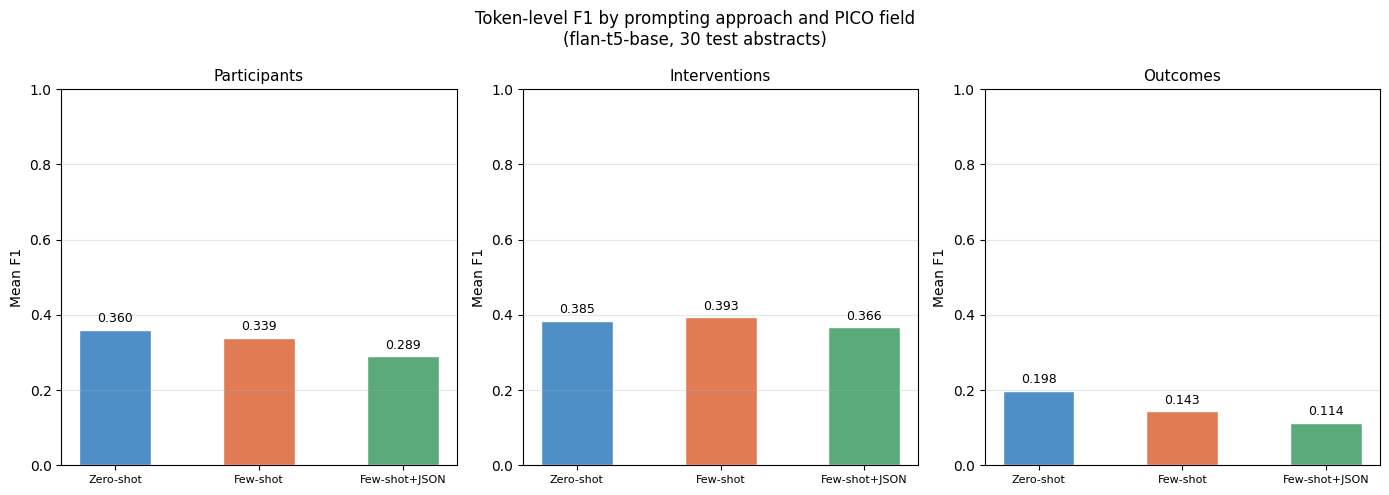

In [ ]:
output_dir = Path("output/03_llm_prompting_output")
output_dir.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle(
    "Token-level F1 by prompting approach and PICO field\n(flan-t5-base, 30 test abstracts)",
    fontsize=12
)
 

labels  = ["Zero-shot", "Few-shot", "Few-shot+JSON"]
colours = ["#4e8fc7", "#e07b54", "#5aaa7a"]
x       = np.arange(3)

for ax, field in zip(axes, FIELDS):
    f1s  = [np.mean([v["f"] for v in scores[n][field]]) for n in APPROACHES]
    bars = ax.bar(x, f1s, color=colours, width=0.5, edgecolor="white")
    ax.set_title(field.capitalize(), fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_ylabel("Mean F1")
    ax.set_ylim(0, 1.0)
    ax.grid(axis="y", alpha=0.3)
    for bar, val in zip(bars, f1s):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.02,
                f"{val:.3f}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig(output_dir / "saisha_f1_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## Precision vs Recall trade-off

Each point is one approach × one field, averaged over 50 abstracts. Dashed grey curves show iso-F1 contours. All three approaches sit on the high-precision, low-recall side of the plot — they extract conservatively (precision 0.49–0.84) but miss most of the gold tokens (recall 0.08–0.38). For a downstream evidence-synthesis use case, this is the wrong trade-off: missing trials is worse than including a few extra tokens.

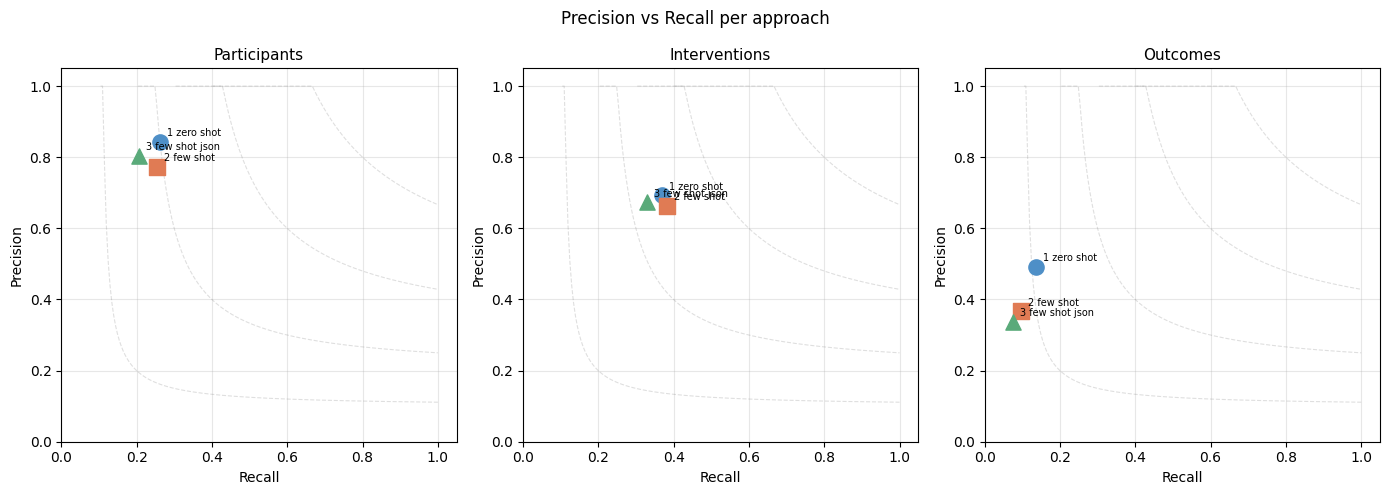

In [35]:


fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("Precision vs Recall per approach", fontsize=12)
markers = ["o", "s", "^"]

for ax, field in zip(axes, FIELDS):
    for name, marker, colour in zip(APPROACHES, markers, colours):
        v     = scores[name][field]
        avg_p = np.mean([x["p"] for x in v])
        avg_r = np.mean([x["r"] for x in v])
        ax.scatter(
            avg_r,
            avg_p,
            marker=marker,
            s=120,
            color=colour,
            label=name.replace("_", " "),
            zorder=3
        )
        ax.annotate(
            name.replace("_", " "),
            (avg_r, avg_p),
            textcoords="offset points",
            xytext=(5, 4),
            fontsize=7
        )

    for f_iso in [0.2, 0.4, 0.6, 0.8]:
        r_vals = np.linspace(0.01, 1, 200)
        denom  = 2 * r_vals - f_iso
        with np.errstate(divide="ignore", invalid="ignore"):
            p_vals = np.where(denom > 0, f_iso * r_vals / denom, np.nan)
        ax.plot(
            r_vals,
            np.clip(p_vals, 0, 1),
            "--",
            color="grey",
            alpha=0.25,
            lw=0.8
        )

    ax.set_xlim(0, 1.05)
    ax.set_ylim(0, 1.05)
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title(field.capitalize(), fontsize=11)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(output_dir / "saisha_precision_recall.png", dpi=150, bbox_inches="tight")
plt.show()

## Qualitative comparison

Side-by-side extractions vs. gold spans for the first three evaluation documents. Useful for spotting systematic failure modes that aggregate metrics hide. Two patterns visible immediately: (i) few-shot copies "Rhinocort Study Group" from the training abstract into the participant slot of doc 10070173 — a priming artefact — and (ii) JSON few-shot returns the literal placeholder `text>` for outcomes when the model fails to commit to an answer.

In [36]:
for doc_id in eval_ids[:3]:
    print("=" * 80)
    print(f"Doc: {doc_id}")
    print("Abstract:", get_abstract_text(doc_id)[:250])
    print()
    for field in FIELDS:
        gold = get_gold_spans(doc_id, field, "test")
        print(f"  {field.upper()}")
        print(f"    Gold         : {' | '.join(gold[:3]) if gold else '(none)'}")
        for name in APPROACHES:
            val = results[name][doc_id][field] or "(empty)"
            print(f"    {name:<20}: {val[:90]}")
    print()

Doc: 10070173
Abstract: Comparison of budesonide Turbuhaler with budesonide aqua in the treatment of seasonal allergic rhinitis . Rhinocort Study Group . OBJECTIVE To compare the effect of budesonide Turbuhaler 400 microg/day with budesonide aqua 256 microg/day in the treat

  PARTICIPANTS
    Gold         : seasonal allergic rhinitis . | Two hundred and eighty-four out-patients | SAR
    1_zero_shot         : patients
    2_few_shot          : Rhinocort Study Group
    3_few_shot_json     : Rhinocort Study Group
  INTERVENTIONS
    Gold         : budesonide Turbuhaler | budesonide aqua | budesonide Turbuhaler
    1_zero_shot         : budesonide
    2_few_shot          : budesonide Turbuhaler
    3_few_shot_json     : budesonide aqua
  OUTCOMES
    Gold         : patients ' preferences | quality of life . | Mean daily nasal symptom scores
    1_zero_shot         : quality of life
    2_few_shot          : Effect of budesonide Turbuhaler on seasonal allergic rhinitis
    3_few_shot_jso

## Error analysis

Decompose errors into:
- **False positives** — predicted tokens not in gold (hallucination)
- **False negatives** — gold tokens not predicted (missed)
- **Empty outputs** — approach returned nothing

In [37]:
rows = []
for name in APPROACHES:
    for doc_id in eval_ids:
        abstract = get_abstract_text(doc_id)
        for field in FIELDS:
            gold = get_gold_tokens(doc_id, field, "test")
            pred = pred_tokens(results[name][doc_id][field])
            fp   = pred - gold
            fn   = gold - pred
            p, r, f = token_f1(gold, pred)
            rows.append({
                "approach": name, "doc_id": doc_id, "field": field,
                "f1": f, "precision": p, "recall": r,
                "n_fp": len(fp), "n_fn": len(fn),
                "empty": len(pred) == 0,
                "abs_len": len(abstract.split()),
                "top_fp": list(fp)[:5],
                "top_fn": list(fn)[:5],
            })

df = pd.DataFrame(rows)

print("Empty output rate:")
print(df.pivot_table(index="approach", columns="field", values="empty", aggfunc="mean").round(2))
print("\nMean false positives:")
print(df.pivot_table(index="approach", columns="field", values="n_fp", aggfunc="mean").round(2))
print("\nMean false negatives:")
print(df.pivot_table(index="approach", columns="field", values="n_fn", aggfunc="mean").round(2))

Empty output rate:
field            interventions  outcomes  participants
approach                                              
1_zero_shot                0.0       0.0           0.0
2_few_shot                 0.0       0.0           0.0
3_few_shot_json            0.0       0.0           0.0

Mean false positives:
field            interventions  outcomes  participants
approach                                              
1_zero_shot               1.20      3.12          0.48
2_few_shot                1.64      3.84          0.56
3_few_shot_json           0.96      2.08          0.40

Mean false negatives:
field            interventions  outcomes  participants
approach                                              
1_zero_shot               5.62     15.68         11.46
2_few_shot                5.34     16.18         11.64
3_few_shot_json           5.58     16.64         12.12


## Effect of abstract length on F1

flan-t5-base has a 512-token input limit. Long abstracts plus a few-shot block push content past this boundary, which should hurt recall. Empirically the effect is field-specific: F1 falls with abstract length for **Participants** (the regression slope is clearly negative), is roughly flat for **Interventions**, and trends slightly **upward** for **Outcomes** — longer abstracts tend to mention more outcomes, giving the model more chances to land on a gold token even after truncation. The truncation hypothesis only holds for Participants.

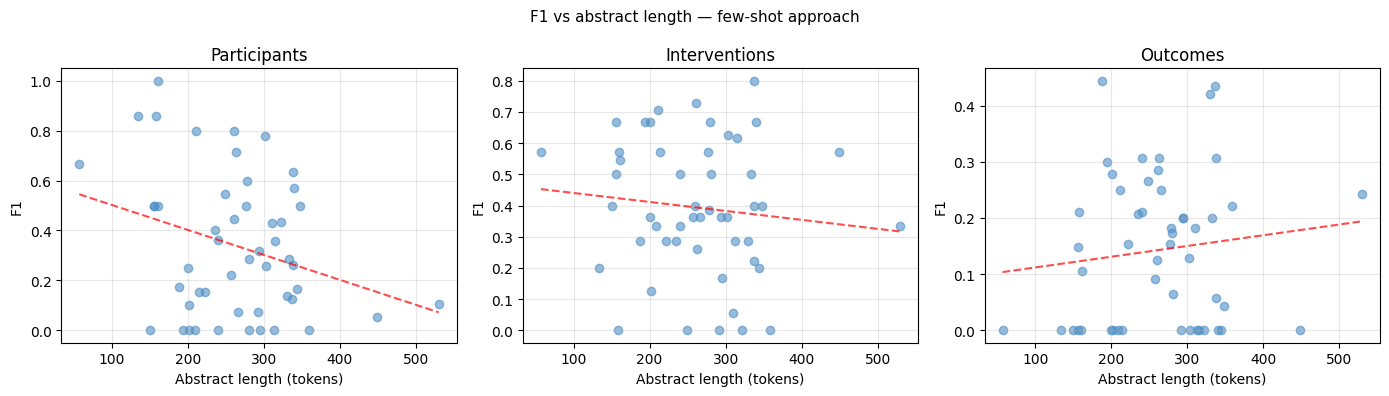

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("F1 vs abstract length — few-shot approach", fontsize=11)

df_fs = df[df["approach"] == "2_few_shot"]

for ax, field in zip(axes, FIELDS):
    sub = df_fs[df_fs["field"] == field]
    ax.scatter(sub["abs_len"], sub["f1"], alpha=0.6, color="#4e8fc7")

    z = np.polyfit(sub["abs_len"], sub["f1"], 1)
    xr = np.linspace(sub["abs_len"].min(), sub["abs_len"].max(), 100)
    ax.plot(xr, np.poly1d(z)(xr), "r--", lw=1.5, alpha=0.7)

    ax.set_xlabel("Abstract length (tokens)")
    ax.set_ylabel("F1")
    ax.set_title(field.capitalize())
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(output_dir / "saisha_length_vs_f1.png", dpi=150, bbox_inches="tight")
plt.show()

## Most frequently missed and hallucinated tokens

Identifies systematic patterns — which content the model consistently fails to extract, and which off-topic tokens it consistently invents.

In [39]:
print("Most frequently missed tokens per field:")
for field in FIELDS:
    missed = []
    for name in APPROACHES:
        for _, row in df[(df["approach"] == name) & (df["field"] == field)].iterrows():
            missed.extend(row["top_fn"])
    print(f"  {field}: {Counter(missed).most_common(8)}")

print()
print("Most frequently hallucinated tokens per field:")
for field in FIELDS:
    halluc = []
    for name in APPROACHES:
        for _, row in df[(df["approach"] == name) & (df["field"] == field)].iterrows():
            halluc.extend(row["top_fp"])
    print(f"  {field}: {Counter(halluc).most_common(8)}")

Most frequently missed tokens per field:
  participants: [('patients', 35), ('with', 31), ('.', 27), ('and', 21), ('of', 21), ('in', 12), ('(', 10), ('from', 9)]
  interventions: [('(', 49), ('.', 32), (')', 31), ('placebo', 24), ('e', 9), ('of', 7), ('and', 7), (']', 6)]
  outcomes: [('of', 56), ('and', 52), (',', 18), ('serum', 17), ('overall', 11), ('adverse', 10), ('(', 10), ('diastolic', 9)]

Most frequently hallucinated tokens per field:
  participants: [('with', 7), ('patients', 4), ('controlled', 3), ('study', 3), ('placebo', 3), ('pospartal', 3), ('a', 2), ('rhinocort', 2)]
  interventions: [('or', 12), ('and', 11), ('with', 9), ('of', 6), ('a', 5), ('versus', 5), ('intake', 3), ('root', 3)]
  outcomes: [('with', 16), ('in', 16), ('specified', 15), ('not', 15), ('of', 13), ('and', 12), ('effect', 11), ('on', 6)]


## Downstream usability

Can the extracted tables actually be queried? We test four keyword queries — the project-standard set defined in `src/eval.py` — and compare match counts against the gold-truth match counts. The placebo query is the most revealing: 11 of 50 trials are placebo-controlled in the gold annotations, but every prompting approach retrieves only 1. Aggregate F1 hides a complete failure mode for the most common kind of clinical query.

In [40]:
from src.eval import DEFAULT_QUERIES
queries = DEFAULT_QUERIES

print(f"{'Query':<30} {'Approach':<22} {'Matches':>8} {'Gold':>6}")
print("-" * 70)
for field, kw, desc in queries:
    gold_matches = sum(
        1 for d in eval_ids
        if any(kw.lower() in s.lower() for s in get_gold_spans(d, field, "test"))
    )
    for name in APPROACHES:
        matches = sum(1 for d in eval_ids if kw.lower() in results[name][d][field].lower())
        print(f"{desc:<30} {name:<22} {matches:>8}     {gold_matches:>3}")
    print()

Query                          Approach                Matches   Gold
----------------------------------------------------------------------
Trials with placebo            1_zero_shot                   1      11
Trials with placebo            2_few_shot                    1      11
Trials with placebo            3_few_shot_json               1      11

Trials mentioning patients     1_zero_shot                  29      33
Trials mentioning patients     2_few_shot                   19      33
Trials mentioning patients     3_few_shot_json              20      33

Trials measuring pain          1_zero_shot                   1       5
Trials measuring pain          2_few_shot                    1       5
Trials measuring pain          3_few_shot_json               1       5

Trials with rehabilitation     1_zero_shot                   0       0
Trials with rehabilitation     2_few_shot                    0       0
Trials with rehabilitation     3_few_shot_json               0       0



## Summary table

Combined Precision/Recall/F1/Coverage table over the 50-document locked set: directly suitable for inclusion in the group report. Coverage is 100% for every approach × field — flan-T5 always returns *something* — but recall is consistently low (8–38%), so high coverage masks low correctness.

In [41]:
print("=" * 78)
print("SUMMARY — flan-t5-base, 30 test abstracts, token-level evaluation")
print("=" * 78)
print(f"{'Approach':<22} {'Field':<15} {'Prec':>6} {'Rec':>6} {'F1':>6} {'Cover':>7}")
print("-" * 78)
for name in APPROACHES:
    for field in FIELDS:
        v        = scores[name][field]
        avg_p    = np.mean([x["p"] for x in v])
        avg_r    = np.mean([x["r"] for x in v])
        avg_f    = np.mean([x["f"] for x in v])
        coverage = sum(1 for d in eval_ids if results[name][d][field].strip()) / len(eval_ids)
        print(f"{name:<22} {field:<15} {avg_p:>6.3f} {avg_r:>6.3f} {avg_f:>6.3f} {coverage:>6.0%}")
    print()

SUMMARY — flan-t5-base, 30 test abstracts, token-level evaluation
Approach               Field             Prec    Rec     F1   Cover
------------------------------------------------------------------------------
1_zero_shot            participants     0.843  0.262  0.360   100%
1_zero_shot            interventions    0.693  0.369  0.385   100%
1_zero_shot            outcomes         0.493  0.137  0.198   100%

2_few_shot             participants     0.773  0.255  0.339   100%
2_few_shot             interventions    0.663  0.382  0.393   100%
2_few_shot             outcomes         0.367  0.097  0.143   100%

3_few_shot_json        participants     0.803  0.208  0.289   100%
3_few_shot_json        interventions    0.673  0.330  0.366   100%
3_few_shot_json        outcomes         0.337  0.075  0.114   100%



## Findings

**Headline result:** Zero-shot achieved the highest macro F1 (0.314), beating few-shot (0.292) and few-shot+JSON (0.256) — opposite to our hypothesis. The few-shot variant edged zero-shot only on Interventions (0.393 vs 0.385), and the paired bootstrap confirms this gap is not statistically significant.

**Statistically significant differences (paired bootstrap, 95% CI):**
- Zero-shot beats few-shot+JSON on Participants (Δ = +0.070) and Outcomes (Δ = +0.084).
- Zero-shot beats few-shot on Outcomes (Δ = +0.054).
- Few-shot beats few-shot+JSON on Participants (Δ = +0.050).
- All Interventions comparisons are within noise.

So the prompting axis matters most for Outcomes (where the JSON wrapper actively hurts) and least for Interventions (where named drugs anchor the answer regardless of prompt format).

**Three systematic failure modes explain the rest:**

1. **Few-shot priming bias** — the model copied "Rhinocort Study Group" from a training example into the participants field of unrelated documents (visible in the qualitative comparison for doc 10070173).
2. **JSON placeholder leakage** — the literal string "not specified" appeared 15 times in outcome predictions, by far the most common hallucinated token. This is the JSON wrapper's failure mode: when the model can't decide on an answer, it copies the few-shot fallback verbatim.
3. **Length sensitivity is field-specific** — F1 drops with abstract length for Participants (the entity usually appears once, near the start, and gets pushed out of the truncation window), is flat for Interventions, and rises slightly for Outcomes (longer abstracts contain more outcome mentions, so even after truncation the model has more chances to hit a gold token).

**Coverage vs. usability:** All three approaches achieved 100% coverage but recall capped at 38%. The downstream test exposed the cost: 1 of 11 placebo-controlled trials in the gold set was retrievable by any approach, and 19–29 of 33 patient-mentioning trials. For clinical evidence synthesis, this is the wrong precision–recall trade-off — high precision with low recall means most relevant trials are silently dropped from any query result.

## Bootstrap confidence intervals

With 50 evaluation documents the gap between zero-shot (macro F1 0.314) and few-shot (0.292) is small relative to per-document variance. We run a paired bootstrap (2000 resamples) to put confidence intervals on the per-approach mean F1 and on the pairwise differences. The pairwise table below is what should be cited in the report — only the comparisons marked `sig` are claims the data actually supports.

In [42]:
import numpy as np

def bootstrap_ci(per_doc_f1, n_iter=2000, alpha=0.05, seed=42):
    rng = np.random.default_rng(seed)
    arr = np.asarray(per_doc_f1)
    n = len(arr)
    means = []
    for _ in range(n_iter):
        idx = rng.integers(0, n, size=n)
        means.append(arr[idx].mean())
    means = np.sort(means)
    lo = means[int(alpha/2 * n_iter)]
    hi = means[int((1 - alpha/2) * n_iter)]
    return arr.mean(), lo, hi


print(f"{'Approach':<22} {'Field':<15} {'F1 mean':>8} {'95% CI':>20}")
print('-' * 70)
for name in APPROACHES:
    for field in FIELDS:
        f1s = [v['f'] for v in scores[name][field]]
        m, lo, hi = bootstrap_ci(f1s)
        print(f'{name:<22} {field:<15} {m:>8.3f}    [{lo:.3f}, {hi:.3f}]')
    print()


Approach               Field            F1 mean               95% CI
----------------------------------------------------------------------
1_zero_shot            participants       0.360    [0.284, 0.435]
1_zero_shot            interventions      0.385    [0.316, 0.454]
1_zero_shot            outcomes           0.198    [0.149, 0.250]

2_few_shot             participants       0.339    [0.261, 0.421]
2_few_shot             interventions      0.393    [0.332, 0.452]
2_few_shot             outcomes           0.143    [0.107, 0.180]

3_few_shot_json        participants       0.289    [0.214, 0.369]
3_few_shot_json        interventions      0.366    [0.300, 0.431]
3_few_shot_json        outcomes           0.114    [0.078, 0.154]



In [43]:
# Pairwise paired-bootstrap on mean F1 differences
def paired_bootstrap_diff(f1_a, f1_b, n_iter=2000, seed=42):
    rng = np.random.default_rng(seed)
    a = np.asarray(f1_a); b = np.asarray(f1_b)
    diffs = []
    n = len(a)
    for _ in range(n_iter):
        idx = rng.integers(0, n, size=n)
        diffs.append(a[idx].mean() - b[idx].mean())
    diffs = np.sort(diffs)
    lo, hi = diffs[int(0.025 * n_iter)], diffs[int(0.975 * n_iter)]
    return float(np.mean(diffs)), float(lo), float(hi)


pairs = [('1_zero_shot', '2_few_shot'), ('1_zero_shot', '3_few_shot_json'), ('2_few_shot', '3_few_shot_json')]
for name_a, name_b in pairs:
    for field in FIELDS:
        a = [v['f'] for v in scores[name_a][field]]
        b = [v['f'] for v in scores[name_b][field]]
        d, lo, hi = paired_bootstrap_diff(a, b)
        sig = 'sig' if (lo > 0 or hi < 0) else 'n.s.'
        print(f'{name_a} - {name_b}  {field:<15} delta={d:+.3f}  CI=[{lo:+.3f}, {hi:+.3f}]  ({sig})')
    print()


1_zero_shot - 2_few_shot  participants    delta=+0.020  CI=[-0.045, +0.086]  (n.s.)
1_zero_shot - 2_few_shot  interventions   delta=-0.008  CI=[-0.061, +0.053]  (n.s.)
1_zero_shot - 2_few_shot  outcomes        delta=+0.054  CI=[+0.004, +0.110]  (sig)

1_zero_shot - 3_few_shot_json  participants    delta=+0.070  CI=[+0.012, +0.134]  (sig)
1_zero_shot - 3_few_shot_json  interventions   delta=+0.019  CI=[-0.049, +0.092]  (n.s.)
1_zero_shot - 3_few_shot_json  outcomes        delta=+0.084  CI=[+0.037, +0.135]  (sig)

2_few_shot - 3_few_shot_json  participants    delta=+0.050  CI=[+0.018, +0.086]  (sig)
2_few_shot - 3_few_shot_json  interventions   delta=+0.027  CI=[-0.018, +0.075]  (n.s.)
2_few_shot - 3_few_shot_json  outcomes        delta=+0.030  CI=[-0.009, +0.065]  (n.s.)



## Limitations

* **Single model family.** All three approaches use `flan-t5-base` (≈250M parameters). Stronger instruction-tuned models or biomedical-specific encoders (e.g. PubMedBERT-based generators) would likely close the gap to the supervised approaches in notebook 06; this notebook only characterises the prompting axis, holding the model fixed.
* **Truncation.** Abstracts and few-shot blocks are clipped to fit the 512-token input window. The Participants F1-vs-length slope shows this matters for entities that appear early in the abstract.
* **Token-overlap F1 is lenient.** A model that returns "patients" gets partial credit for a gold span like "Two hundred and eighty-four out-patients with seasonal allergic rhinitis." Strict span F1 in notebooks 04/06 will give lower numbers for the same predictions.
* **Comparator.** EBM-NLP folds comparators into the Interventions field (Nye et al., 2018), so this notebook does not extract the comparator separately. Notebook 05 attempts a post-hoc keyword split.

## Save predictions for the master comparison


In [44]:
from src.eval import save_predictions

save_predictions('zero_shot_flan_t5',     {d: {f: results['1_zero_shot'][d][f]     for f in FIELDS} for d in eval_ids})
save_predictions('few_shot_flan_t5',      {d: {f: results['2_few_shot'][d][f]      for f in FIELDS} for d in eval_ids})
save_predictions('few_shot_json_flan_t5', {d: {f: results['3_few_shot_json'][d][f] for f in FIELDS} for d in eval_ids})
print('Saved predictions for the three flan-T5 prompting approaches to ./predictions/')

Saved predictions for the three flan-T5 prompting approaches to ./predictions/


## Note: comparator (PICO C)

This notebook only extracts P, I, O. EBM-NLP folds the **comparator** into the Interventions field by design — see Nye et al. (2018). The report cites this as a dataset-level limitation rather than a method-level one. Notebook 05 attempts comparator recovery as a post-processing step on the extracted intervention spans by detecting comparison markers (`vs`, `placebo`, `control`).